# Planet Manifest Summary

Run this notebook from conda env `analysis`.

This notebook summarizes the raw `chip_order_manifest.json` outputs written by the `fetch_ps_chip_manifest` snakemake rule. It focuses on search returns only: all `ortho_analytic_4b_sr` scenes intersecting each chip AOI within the configured search window.

In [1]:
import os
from pathlib import Path

os.chdir('/workspace')
Path.cwd()

PosixPath('/workspace')

## Load Manifest Files

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
out_dir = Path('/workspace/_outputs')
manifest_fp_l = sorted(out_dir.rglob('chip_order_manifest.json'))
len(manifest_fp_l)

366

## Build Scene-Level and Chip-Level Tables

In [3]:
chip_meta_l = []
scene_meta_l = []

for manifest_fp in manifest_fp_l:
    manifest_d = json.loads(manifest_fp.read_text())
    chip_context = manifest_d['chip_context']
    summary_rows = manifest_d.get('summary_rows', [])
    sensor_l = sorted({(row.get('instrument') or 'UNKNOWN') for row in summary_rows})
    chip_meta_l.append({
        'event': chip_context['event'],
        'chip_id': chip_context['chip_id'],
        'reference_datetime': chip_context['reference_datetime'],
        'search_window_start': chip_context['search_window_start'],
        'search_window_end': chip_context['search_window_end'],
        'n_returned': len(summary_rows),
        'n_full_coverage': sum(bool(row.get('covers_chip')) for row in summary_rows),
        'n_within_24h': sum(bool(row.get('within_24h')) for row in summary_rows),
        'closest_time_delta_hours': min([row.get('time_delta_hours') for row in summary_rows], default=None),
        'sensor_values': ','.join(sensor_l),
    })
    for row in summary_rows:
        scene_meta_l.append({
            'event': chip_context['event'],
            'chip_id': chip_context['chip_id'],
            **row,
        })

chip_df = pd.DataFrame(chip_meta_l).sort_values(['event', 'chip_id']).reset_index(drop=True)
scene_df = pd.DataFrame(scene_meta_l).sort_values(['event', 'chip_id', 'time_delta_hours']).reset_index(drop=True)

print(f'loaded {len(chip_df):,} chip manifests')
print(f'loaded {len(scene_df):,} returned scenes')
chip_df.head()

loaded 366 chip manifests
loaded 2,778 returned scenes


,event,chip_id,reference_datetime,search_window_start,search_window_end,n_returned,n_full_coverage,n_within_24h,closest_time_delta_hours,sensor_values
0,Bangladesh,BGD_40_119,2017-03-14T03:45:00+00:00,2017-03-11T03:45:00+00:00,2017-03-17T03:45:00+00:00,4,1,2,0.017,PS2
1,Bangladesh,BGD_43_99,2017-03-14T03:45:00+00:00,2017-03-11T03:45:00+00:00,2017-03-17T03:45:00+00:00,4,0,2,0.014,PS2
2,Bangladesh,BGD_45_90,2017-03-14T03:45:00+00:00,2017-03-11T03:45:00+00:00,2017-03-17T03:45:00+00:00,4,0,2,0.013,PS2
3,Bangladesh,BGD_50_67,2017-03-14T03:45:00+00:00,2017-03-11T03:45:00+00:00,2017-03-17T03:45:00+00:00,6,2,2,0.010,PS2
4,Bangladesh,BGD_50_83,2017-03-14T03:45:00+00:00,2017-03-11T03:45:00+00:00,2017-03-17T03:45:00+00:00,1,1,1,0.012,PS2


## Per-Event Summary Table

In [4]:
event_summary_df = chip_df.groupby('event', as_index=False).agg(
    n_chips=('chip_id', 'size'),
    total_returned=('n_returned', 'sum'),
    total_full_coverage=('n_full_coverage', 'sum'),
    mean_returned_per_chip=('n_returned', 'mean'),
    mean_full_coverage_per_chip=('n_full_coverage', 'mean'),
).sort_values('total_returned', ascending=False)

event_summary_df

,event,n_chips,total_returned,total_full_coverage,mean_returned_per_chip,mean_full_coverage_per_chip
1,Bolivia,100,481,153,4.810000,1.530000
8,Somalia,20,208,77,10.400000,3.850000
9,Spain,20,181,68,9.050000,3.400000
15,US-Nebraska,16,180,41,11.250000,2.562500
12,US-Carolina,15,174,45,11.600000,3.000000
13,US-Dakota,14,172,62,12.285714,4.428571
14,US-Kansas,20,157,57,7.850000,2.850000
10,US-Alabama,16,155,47,9.687500,2.937500
2,Cambodia,20,151,48,7.550000,2.400000
18,Uzbekistan,12,150,41,12.500000,3.416667


## Returned Scenes Per Chip Grouped by Event

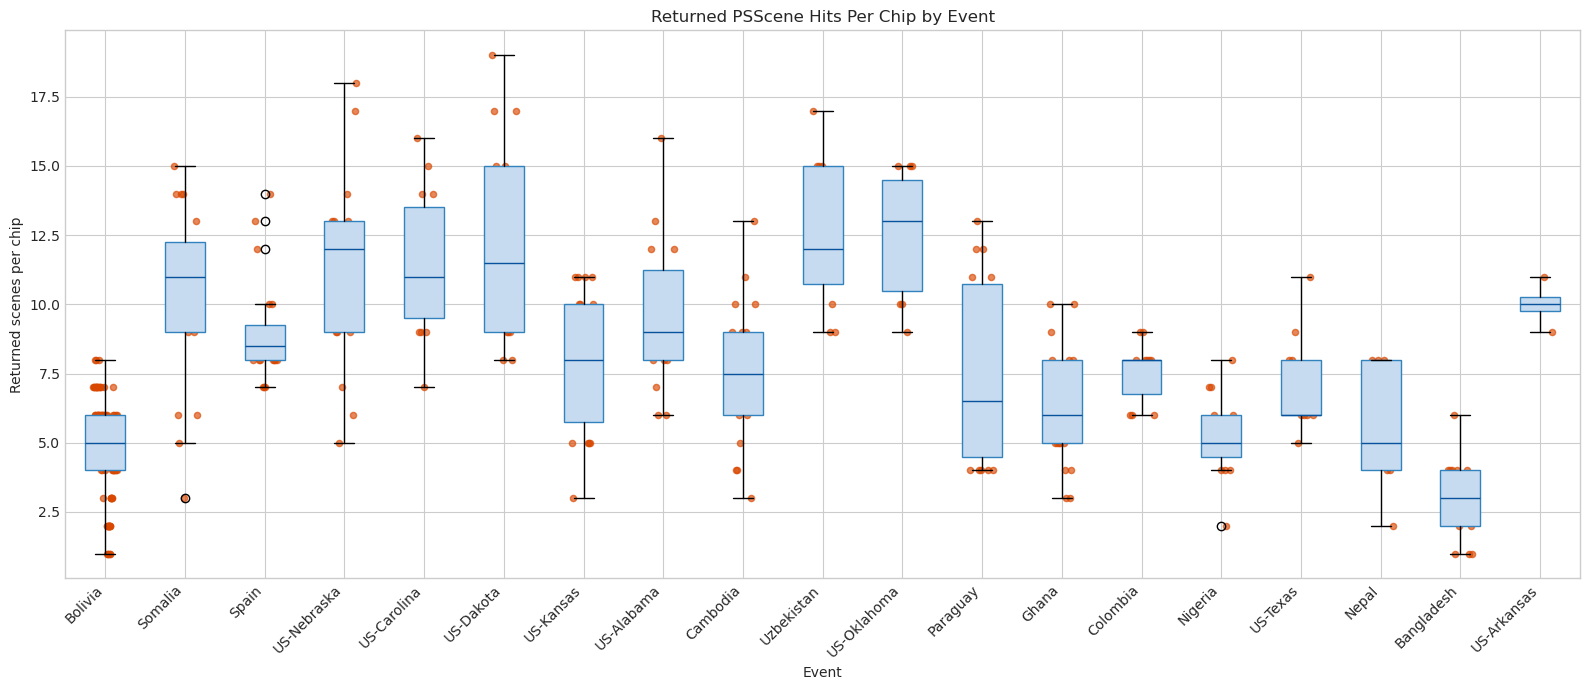

In [5]:
event_order = event_summary_df['event'].tolist()
value_l = [chip_df.loc[chip_df['event'] == event, 'n_returned'].tolist() for event in event_order]
fig, ax = plt.subplots(figsize=(16, 7))
ax.boxplot(value_l, patch_artist=True, boxprops={'facecolor': '#c6dbef', 'edgecolor': '#3182bd'}, medianprops={'color': '#08519c'})
for i, event in enumerate(event_order, start=1):
    y = chip_df.loc[chip_df['event'] == event, 'n_returned'].to_numpy()
    x = np.linspace(i - 0.15, i + 0.15, len(y)) if len(y) > 1 else np.array([i])
    ax.scatter(x, y, color='#d94801', alpha=0.65, s=20)
ax.set_title('Returned PSScene Hits Per Chip by Event')
ax.set_xlabel('Event')
ax.set_ylabel('Returned scenes per chip')
ax.set_xticks(range(1, len(event_order) + 1))
ax.set_xticklabels(event_order, rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Returned vs Full-Coverage Scenes by Event

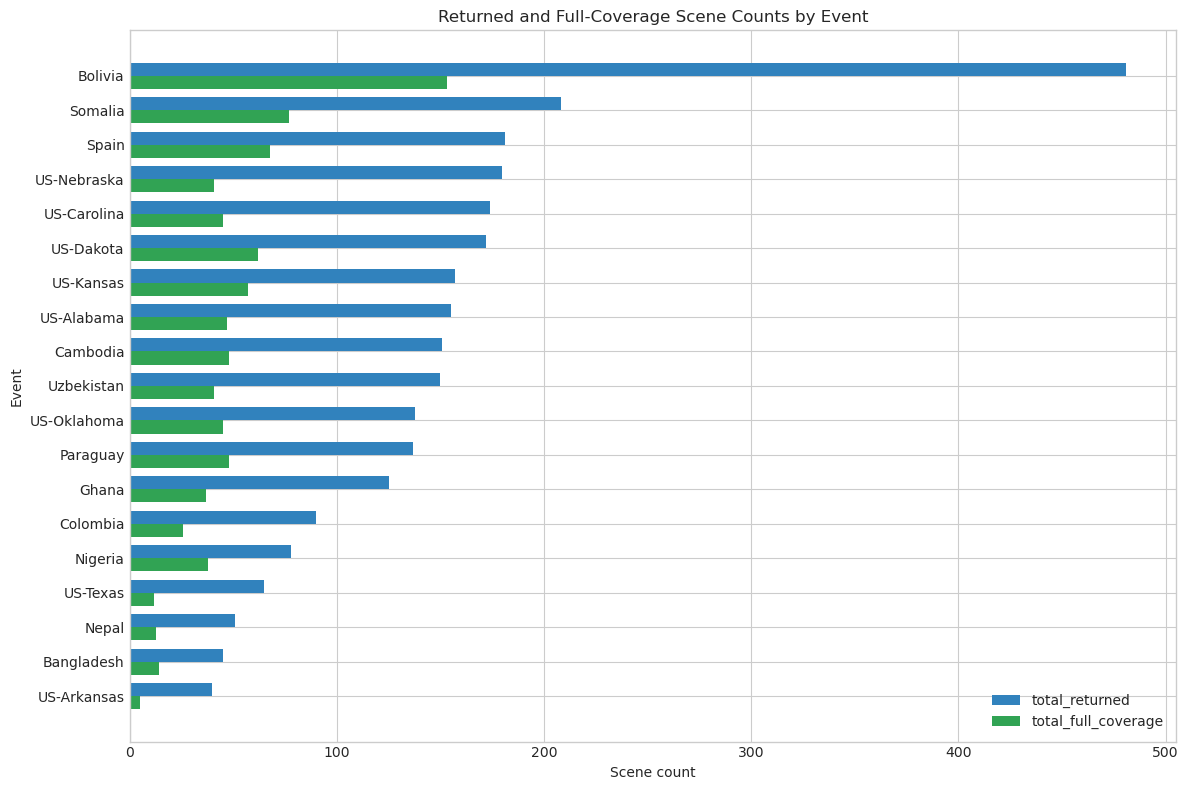

In [6]:
plot_df = event_summary_df.set_index('event')[['total_returned', 'total_full_coverage']].loc[event_order]
fig, ax = plt.subplots(figsize=(12, 8))
y = np.arange(len(plot_df))
bar_h = 0.38
ax.barh(y - bar_h / 2, plot_df['total_returned'], height=bar_h, color='#3182bd', label='total_returned')
ax.barh(y + bar_h / 2, plot_df['total_full_coverage'], height=bar_h, color='#31a354', label='total_full_coverage')
ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)
ax.invert_yaxis()
ax.set_title('Returned and Full-Coverage Scene Counts by Event')
ax.set_xlabel('Scene count')
ax.set_ylabel('Event')
ax.legend()
plt.tight_layout()
plt.show()

## Sensor Mix Across Returned Scenes

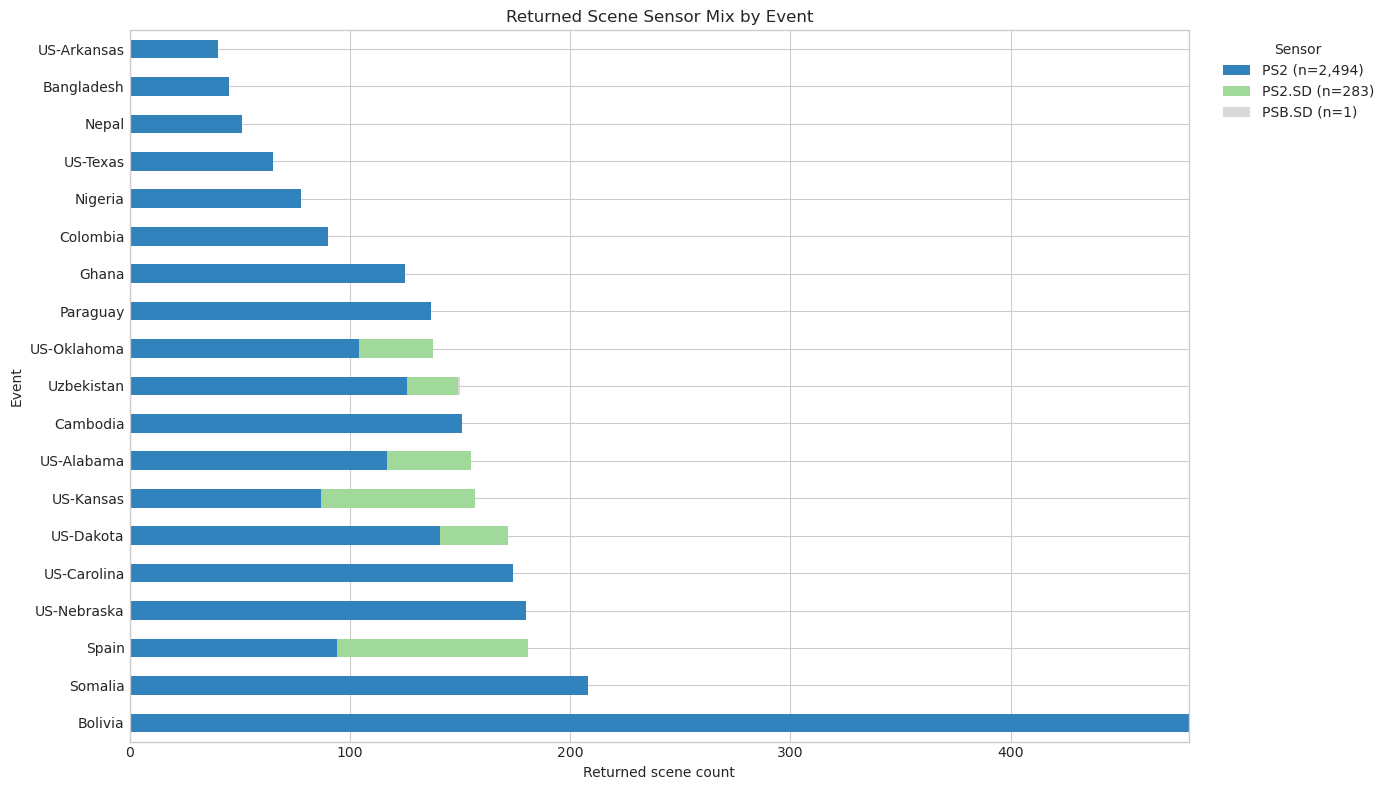

In [7]:
sensor_df = scene_df.copy()
sensor_df['instrument'] = sensor_df['instrument'].fillna('UNKNOWN')
sensor_plot_df = sensor_df.groupby(['event', 'instrument']).size().rename('count').reset_index()
sensor_pivot_df = sensor_plot_df.pivot(index='event', columns='instrument', values='count').fillna(0).loc[event_order]
sensor_total_s = sensor_pivot_df.sum(axis=0).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 8))
sensor_pivot_df.plot(kind='barh', stacked=True, ax=ax, colormap='tab20c')
ax.set_title('Returned Scene Sensor Mix by Event')
ax.set_xlabel('Returned scene count')
ax.set_ylabel('Event')
handles, labels = ax.get_legend_handles_labels()
label_d = {label: f'{label} (n={int(sensor_total_s.get(label, 0)):,})' for label in labels}
ax.legend(handles, [label_d[label] for label in labels], title='Sensor', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Time Offset Distribution for Full-Coverage Scenes

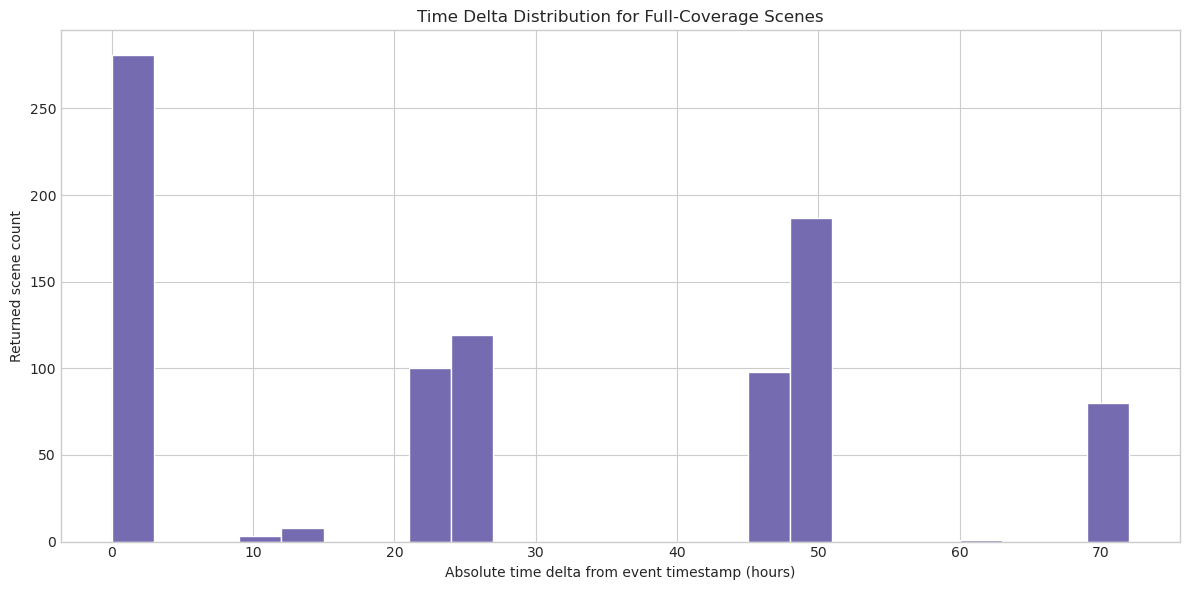

In [8]:
full_cover_df = scene_df.loc[scene_df['covers_chip'].fillna(False)].copy()
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(full_cover_df['time_delta_hours'].dropna(), bins=24, color='#756bb1', edgecolor='white')
ax.set_title('Time Delta Distribution for Full-Coverage Scenes')
ax.set_xlabel('Absolute time delta from event timestamp (hours)')
ax.set_ylabel('Returned scene count')
plt.tight_layout()
plt.show()